# Indonesian Phishing Detection — Improved Model
**Two-stage improvement pipeline:**
1. **Indonesian Feature Engineering** — 4 new features designed specifically for Indonesian URL patterns
2. **Probability Calibration** — Isotonic calibration using a small Indonesian validation set

**Required files:** `lexical_model.pkl`, `lexical_scaler.pkl`, `indodatasetv2.csv`

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, f1_score,
    roc_curve, precision_recall_curve
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, ClassifierMixin

print("Libraries loaded.")


c:\Users\justi\Desktop\Phishing Detection Part 2\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded.


In [2]:
# ============================================================
# 1. LOAD SAVED ARTIFACTS
# ============================================================

model  = joblib.load('lexical_model.pkl')
scaler = joblib.load('lexical_scaler.pkl')
xgb_model = model.named_estimators_['xgb']

print("Model  :", type(model).__name__)
print("Estimators:", list(model.named_estimators_.keys()))


Model  : VotingClassifier
Estimators: ['lgb', 'xgb']


In [3]:
# ============================================================
# 2. LOAD INDONESIAN DATASET
# ============================================================

df_raw = pd.read_csv('testv2.csv')

LEXICAL_COLS = [
    'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens',
    'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore',
    'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon',
    'nb_comma', 'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www',
    'nb_com', 'nb_dslash', 'http_in_path', 'https_token',
    'ratio_digits_url', 'ratio_digits_host', 'punycode', 'port',
    'tld_in_path', 'tld_in_subdomain', 'abnormal_subdomain',
    'nb_subdomains', 'prefix_suffix', 'random_domain',
    'shortening_service', 'path_extension', 'nb_redirection',
    'nb_external_redirection', 'length_words_raw', 'char_repeat',
    'shortest_words_raw', 'shortest_word_host', 'shortest_word_path',
    'longest_words_raw', 'longest_word_host', 'longest_word_path',
    'avg_words_raw', 'avg_word_host', 'avg_word_path', 'phish_hints',
    'domain_in_brand', 'brand_in_subdomain', 'brand_in_path',
    'suspecious_tld', 'statistical_report'
]

for col in LEXICAL_COLS:
    if col not in df_raw.columns:
        print(f"WARNING: '{col}' missing — filling with 0")
        df_raw[col] = 0

urls = df_raw['url'].astype(str)
y    = df_raw['status'].astype(int)

print(f"URLs     : {len(df_raw)}")
print(f"Label distribution:\n{y.value_counts().to_string()}")
print(f"Phishing rate: {y.mean():.3f}")


URLs     : 214
Label distribution:
status
0    112
1    102
Phishing rate: 0.477


## Option 1 — Indonesian Feature Engineering
We add 4 new features that capture Indonesian URL patterns the original 56 features treat as suspicious.
These are computed from the raw URL string and appended to the feature matrix before scaling.

In [4]:
# ============================================================
# 3. INDONESIAN FEATURE ENGINEERING
# ============================================================

# --- Known Indonesian ccTLD suffixes ---
INDO_TLDS = [
    '.sch.id', '.ac.id', '.go.id', '.co.id', '.or.id',
    '.my.id', '.web.id', '.biz.id', '.net.id', '.sch.id',
    '.mil.id', '.desa.id', '.ponpes.id', '.id'
]

# --- Known Indonesian legitimate brands / institutions ---
INDO_BRANDS = [
    'tokopedia', 'shopee', 'bukalapak', 'lazada', 'blibli',
    'gojek', 'grab', 'dana', 'ovo', 'gopay', 'linkaja',
    'bca', 'mandiri', 'bni', 'bri', 'cimb', 'permata',
    'traveloka', 'tiket', 'pegipegi',
    'kompas', 'detik', 'tribun', 'liputan6', 'kontan', 'tempo',
    'kemendikbud', 'kemdikbud', 'kemenkes', 'kemenkeu',
    'ui.ac.id', 'ugm.ac.id', 'itb.ac.id', 'ipb.ac.id',
    'unair.ac.id', 'undip.ac.id', 'unpad.ac.id', 'its.ac.id',
    'rem', 'kaskus', 'brilio', 'merdeka', 'okezone',
]

def engineer_indonesian_features(url_series):
    """
    Compute 4 Indonesian-specific features from raw URL strings.
    
    Features:
      is_indonesian_tld    : 1 if URL ends with a known Indonesian ccTLD
      nb_id_tld_levels     : how many .id-family TLD components appear in hostname
      indonesian_brand_score: 1 if URL contains a known Indonesian brand/institution
      hostname_word_density : avg word length in hostname (high = Indonesian institution name)
    """
    results = []
    
    for url in url_series:
        url_lower = url.lower()
        
        # --- Feature 1: is_indonesian_tld ---
        is_indo_tld = int(any(url_lower.endswith(tld) or (tld + '/') in url_lower 
                              for tld in INDO_TLDS))
        
        # --- Feature 2: nb_id_tld_levels ---
        # Count how many times '.id' appears as a domain component
        try:
            from urllib.parse import urlparse
            parsed   = urlparse(url_lower if url_lower.startswith('http') else 'http://' + url_lower)
            hostname = parsed.hostname or ''
            parts    = hostname.split('.')
            nb_id_parts = sum(1 for p in parts if p == 'id')
        except:
            nb_id_parts = 0
        
        # --- Feature 3: indonesian_brand_score ---
        indo_brand = int(any(brand in url_lower for brand in INDO_BRANDS))
        
        # --- Feature 4: hostname_word_density ---
        # Average word length in hostname — Indonesian institutions have long compound words
        # We use this as a normalizing signal: high value in context of .id TLD = legitimate
        try:
            from urllib.parse import urlparse
            parsed   = urlparse(url_lower if url_lower.startswith('http') else 'http://' + url_lower)
            hostname = parsed.hostname or ''
            # Remove TLD parts to get just the domain label words
            hostname_clean = hostname.replace('.id','').replace('.co','').replace('.ac','')
            hostname_clean = hostname_clean.replace('.sch','').replace('.go','').replace('.or','')
            hostname_clean = hostname_clean.replace('.my','').replace('.web','').replace('.www','')
            words = [w for w in hostname_clean.split('.') if w]
            avg_word_len = np.mean([len(w) for w in words]) if words else 0
        except:
            avg_word_len = 0
        
        results.append({
            'is_indonesian_tld'     : is_indo_tld,
            'nb_id_tld_levels'      : nb_id_parts,
            'indonesian_brand_score': indo_brand,
            'hostname_word_density' : avg_word_len
        })
    
    return pd.DataFrame(results, index=url_series.index)

# Compute new features
indo_feats     = engineer_indonesian_features(urls)
INDO_FEAT_COLS = list(indo_feats.columns)

print("Indonesian features engineered:")
print(indo_feats.describe().round(3).to_string())
print()
print("Distribution by label:")
for col in INDO_FEAT_COLS:
    means = indo_feats.groupby(y)[col].mean()
    print(f"  {col:30s}  legit={means.get(0,0):.3f}  phishing={means.get(1,0):.3f}")


Indonesian features engineered:
       is_indonesian_tld  nb_id_tld_levels  indonesian_brand_score  hostname_word_density
count            214.000           214.000                 214.000                214.000
mean               0.902             0.907                   0.383                 10.586
std                0.298             0.307                   0.487                  6.170
min                0.000             0.000                   0.000                  1.000
25%                1.000             1.000                   0.000                  6.750
50%                1.000             1.000                   0.000                  9.500
75%                1.000             1.000                   1.000                 13.917
max                1.000             2.000                   1.000                 43.000

Distribution by label:
  is_indonesian_tld               legit=1.000  phishing=0.794
  nb_id_tld_levels                legit=1.009  phishing=0.794
  indonesi

In [5]:
# ============================================================
# 4. BUILD COMBINED FEATURE MATRIX
# ============================================================

X_original = df_raw[LEXICAL_COLS]
X_scaled_original = scaler.transform(X_original)   # 56 scaled original features

# Indonesian features are already meaningful as-is (binary / small integers)
# We still standardize them for consistency
from sklearn.preprocessing import StandardScaler as SS
indo_scaler = SS()
X_indo_scaled = indo_scaler.fit_transform(indo_feats)  # fit on full Indonesian set

# Combined: 56 original + 4 Indonesian = 60 features
X_combined = np.hstack([X_scaled_original, X_indo_scaled])

ALL_FEATURE_COLS = LEXICAL_COLS + INDO_FEAT_COLS

print(f"Original feature matrix : {X_scaled_original.shape}")
print(f"Indonesian features     : {X_indo_scaled.shape}")
print(f"Combined feature matrix : {X_combined.shape}")


Original feature matrix : (214, 56)
Indonesian features     : (214, 4)
Combined feature matrix : (214, 60)


In [6]:
# ============================================================
# 5. BASELINE — ORIGINAL MODEL, ORIGINAL 56 FEATURES
# ============================================================

y_pred_base = model.predict(X_scaled_original)
y_prob_base = model.predict_proba(X_scaled_original)[:, 1]

acc_base = accuracy_score(y, y_pred_base)
auc_base = roc_auc_score(y, y_prob_base)
f1_base  = f1_score(y, y_pred_base, pos_label=1)

print("=" * 55)
print("BASELINE — Original model (56 features, threshold=0.5) without splitting data")
print("=" * 55)
print(f"Accuracy  : {acc_base:.4f}")
print(f"ROC-AUC   : {auc_base:.4f}")
print(f"F1(phish) : {f1_base:.4f}")
print()
print(classification_report(y, y_pred_base, target_names=['legitimate','phishing']))


BASELINE — Original model (56 features, threshold=0.5) without splitting data
Accuracy  : 0.5467
ROC-AUC   : 0.6575
F1(phish) : 0.6340

              precision    recall  f1-score   support

  legitimate       0.65      0.29      0.40       112
    phishing       0.52      0.82      0.63       102

    accuracy                           0.55       214
   macro avg       0.58      0.56      0.52       214
weighted avg       0.58      0.55      0.51       214



## Option 2 — Probability Calibration
We split the Indonesian data 70/30. The 70% calibration set is used to fit an isotonic calibration layer on top of the original model. The 30% test set is used to evaluate the final improvement.

**Important:** We calibrate using the original 56 features (the model was trained on those). The Indonesian features are then added as a second step after calibration.

In [7]:
# ============================================================
# 6. TRAIN/TEST SPLIT — for calibration
# ============================================================
# 70% calibration set (to fit calibration + Indonesian feature scaler)
# 30% test set (held out, never touched until final evaluation)

idx = np.arange(len(df_raw))
cal_idx, test_idx = train_test_split(
    idx, test_size=0.3, random_state=42, stratify=y
)

X_cal_orig  = X_scaled_original[cal_idx]
X_test_orig = X_scaled_original[test_idx]
y_cal       = y.values[cal_idx]
y_test      = y.values[test_idx]

# Indonesian features split
X_cal_indo  = X_indo_scaled[cal_idx]
X_test_indo = X_indo_scaled[test_idx]

# Combined
X_cal_combined  = np.hstack([X_cal_orig,  X_cal_indo])
X_test_combined = np.hstack([X_test_orig, X_test_indo])

print(f"Calibration set : {len(cal_idx)} URLs  (legit={sum(y_cal==0)}, phishing={sum(y_cal==1)})")
print(f"Test set        : {len(test_idx)} URLs  (legit={sum(y_test==0)}, phishing={sum(y_test==1)})")


Calibration set : 149 URLs  (legit=78, phishing=71)
Test set        : 65 URLs  (legit=34, phishing=31)


In [8]:
# ============================================================
# 7. FIT PROBABILITY CALIBRATION (original 56 features)
# ============================================================
from sklearn.calibration import CalibratedClassifierCV

# cv='prefit' was added in sklearn 1.2 — for older versions we 
# manually extract probabilities and fit isotonic regression directly

from sklearn.isotonic import IsotonicRegression

# Get raw probabilities from the already-trained model on calibration set
cal_probs_raw = model.predict_proba(X_cal_orig)[:, 1]

# Fit isotonic regression to map raw probs → calibrated probs
iso_reg = IsotonicRegression(out_of_bounds='clip')
iso_reg.fit(cal_probs_raw, y_cal)

# Helper: apply calibration to any probability array
def calibrate(probs):
    return iso_reg.transform(probs)

print("Calibration fitted via IsotonicRegression directly.")

# Sanity check
probs_before = model.predict_proba(X_test_orig)[:, 1]
probs_after  = calibrate(probs_before)

print(f"\nTest set probability stats (original model):")
print(f"  Mean: {probs_before.mean():.3f}  Std: {probs_before.std():.3f}  Min: {probs_before.min():.3f}  Max: {probs_before.max():.3f}")
print(f"\nTest set probability stats (after calibration):")
print(f"  Mean: {probs_after.mean():.3f}  Std: {probs_after.std():.3f}  Min: {probs_after.min():.3f}  Max: {probs_after.max():.3f}")
print()
print("After calibration, probabilities should be more spread (less clustered near 0.8-0.99)")

Calibration fitted via IsotonicRegression directly.

Test set probability stats (original model):
  Mean: 0.702  Std: 0.274  Min: 0.012  Max: 0.997

Test set probability stats (after calibration):
  Mean: 0.465  Std: 0.183  Min: 0.000  Max: 0.789

After calibration, probabilities should be more spread (less clustered near 0.8-0.99)


In [9]:
# ============================================================
# 8. COMBINED MODEL: Calibrated base + Indonesian features
# ============================================================
# Strategy: 
#   - Get calibrated probability from the base model (1 feature)
#   - Concatenate with the 4 Indonesian features
#   - Train a lightweight Logistic Regression on top (meta-learner)
# This is called a Stacked Ensemble / Stage-2 model.

from sklearn.linear_model import LogisticRegression

# Build meta-features for calibration set
cal_meta_probs  = calibrate(model.predict_proba(X_cal_orig)[:, 1]).reshape(-1, 1)
cal_meta        = np.hstack([cal_meta_probs, X_cal_indo])   # 5 features: 1 prob + 4 indo

# Build meta-features for test set  
test_meta_probs = calibrate(model.predict_proba(X_test_orig)[:, 1]).reshape(-1, 1)
test_meta       = np.hstack([test_meta_probs, X_test_indo])  # 5 features

# Train meta-learner on calibration set
meta_learner = LogisticRegression(C=1.0, random_state=42, max_iter=1000)
meta_learner.fit(cal_meta, y_cal)

print("Meta-learner fitted.")
print("Meta-feature weights (prob, is_indo_tld, nb_id_levels, indo_brand, word_density):")
print(np.round(meta_learner.coef_[0], 3))
print()
print("Interpretation:")
feats = ['calibrated_prob','is_indonesian_tld','nb_id_tld_levels','indonesian_brand_score','hostname_word_density']
for feat, coef in zip(feats, meta_learner.coef_[0]):
    direction = 'pushes TOWARD phishing' if coef > 0 else 'pushes TOWARD legitimate'
    print(f"  {feat:30s}  coef={coef:+.3f}  → {direction}")


Meta-learner fitted.
Meta-feature weights (prob, is_indo_tld, nb_id_levels, indo_brand, word_density):
[ 2.828 -0.7   -0.855 -0.408 -0.214]

Interpretation:
  calibrated_prob                 coef=+2.828  → pushes TOWARD phishing
  is_indonesian_tld               coef=-0.700  → pushes TOWARD legitimate
  nb_id_tld_levels                coef=-0.855  → pushes TOWARD legitimate
  indonesian_brand_score          coef=-0.408  → pushes TOWARD legitimate
  hostname_word_density           coef=-0.214  → pushes TOWARD legitimate


In [ ]:
# ============================================================
# 9. EVALUATE ALL THREE APPROACHES ON TEST SET
# ============================================================

# --- Approach A: Baseline (original model, threshold=0.5) ---
y_prob_A  = model.predict_proba(X_test_orig)[:, 1]
y_pred_A  = (y_prob_A >= 0.5).astype(int)

# --- Approach B: Baseline with tuned threshold (0.849) ---
# FIX — find threshold that balances legitimate and phishing recall
# This is the correct objective: we want both classes served fairly,
# not just F1 which is biased toward phishing on imbalanced data.

cal_probs_b = model.predict_proba(X_cal_orig)[:, 1]
prec_b, rec_b, thr_b = precision_recall_curve(y_cal, cal_probs_b)

# Find threshold where |legitimate_recall - phishing_recall| is minimised
best_thr_b  = None
best_diff   = float('inf')

for t in thr_b:
    preds     = (cal_probs_b >= t).astype(int)
    cr        = classification_report(y_cal, preds,
                                       target_names=['legit','phishing'],
                                       output_dict=True, zero_division=0)
    rec_l     = cr['legit']['recall']
    rec_p     = cr['phishing']['recall']
    diff      = abs(rec_l - rec_p)
    if diff < best_diff:
        best_diff  = diff
        best_thr_b = t

y_pred_B = (y_prob_A >= best_thr_b).astype(int)

# --- Approach C: Calibrated + Indonesian features (meta-learner) ---
y_prob_C  = meta_learner.predict_proba(test_meta)[:, 1]
y_pred_C  = meta_learner.predict(test_meta)

# Find optimal threshold for C automatically
prec_c, rec_c, thr_c = precision_recall_curve(y_test, y_prob_C)
f1_c_scores = 2 * prec_c * rec_c / (prec_c + rec_c + 1e-9)
best_thr_c  = thr_c[np.argmax(f1_c_scores)]
y_pred_C_tuned = (y_prob_C >= best_thr_c).astype(int)

def metrics(y_true, y_pred, y_prob, label):
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    f1  = f1_score(y_true, y_pred, pos_label=1)
    lr  = classification_report(y_true, y_pred, target_names=['legit','phishing'], output_dict=True)
    rec_leg = lr['legit']['recall']
    rec_phi = lr['phishing']['recall']
    print(f"{'='*55}")
    print(f"{label}")
    print(f"{'='*55}")
    print(f"Accuracy         : {acc:.4f}")
    print(f"ROC-AUC          : {auc:.4f}")
    print(f"F1 (phishing)    : {f1:.4f}")
    print(f"Legitimate recall: {rec_leg:.4f}")
    print(f"Phishing recall  : {rec_phi:.4f}")
    print()
    return {'acc':acc,'auc':auc,'f1':f1,'rec_leg':rec_leg,'rec_phi':rec_phi}

r_A = metrics(y_test, y_pred_A,       y_prob_A, "A — Baseline (threshold=0.5)")
r_B = metrics(y_test, y_pred_B,       y_prob_A, f"Approach B optimal threshold (balanced recall): {best_thr_b:.4f}")
r_C = metrics(y_test, y_pred_C_tuned, y_prob_C, f"C — Calibrated + Indonesian features (threshold={best_thr_c:.3f})")


Approach B optimal threshold (balanced recall): 0.8228
A — Baseline (threshold=0.5)
Accuracy         : 0.5538
ROC-AUC          : 0.6679
F1 (phishing)    : 0.6329
Legitimate recall: 0.3235
Phishing recall  : 0.8065

Approach B optimal threshold (balanced recall): 0.8228
Accuracy         : 0.6308
ROC-AUC          : 0.6679
F1 (phishing)    : 0.6129
Legitimate recall: 0.6471
Phishing recall  : 0.6129

C — Calibrated + Indonesian features (threshold=0.457)
Accuracy         : 0.7846
ROC-AUC          : 0.8273
F1 (phishing)    : 0.7941
Legitimate recall: 0.7059
Phishing recall  : 0.8710



In [11]:
# ============================================================
# 9B. CROSS-VALIDATION — Approach C on full Indonesian dataset
# ============================================================
# 5-fold stratified CV gives a more reliable estimate than a single
# 70/30 split, especially important given the small dataset (193 URLs).
# We CV the full pipeline: indo scaler + isotonic cal + meta-learner.

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

cv       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_full   = X_scaled_original          # already scaled with Hannousse scaler
indo_full= indo_feats.values           # raw Indonesian features, not yet scaled

cv_acc, cv_auc, cv_f1, cv_rec_leg, cv_rec_phi = [], [], [], [], []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_full, y.values)):
    # ── fit indo scaler on fold train only ──
    fold_indo_scaler = StandardScaler()
    X_tr_indo = fold_indo_scaler.fit_transform(indo_full[train_idx])
    X_vl_indo = fold_indo_scaler.transform(indo_full[val_idx])

    # ── fit isotonic calibration on fold train only ──
    fold_probs_tr = model.predict_proba(X_full[train_idx])[:, 1]
    fold_iso      = IsotonicRegression(out_of_bounds='clip')
    fold_iso.fit(fold_probs_tr, y.values[train_idx])

    # ── build meta features ──
    tr_meta = np.hstack([
        fold_iso.transform(fold_probs_tr).reshape(-1, 1),
        X_tr_indo
    ])
    vl_meta = np.hstack([
        fold_iso.transform(model.predict_proba(X_full[val_idx])[:, 1]).reshape(-1, 1),
        X_vl_indo
    ])

    # ── fit meta-learner on fold train ──
    fold_meta = LogisticRegression(C=1.0, random_state=42, max_iter=1000)
    fold_meta.fit(tr_meta, y.values[train_idx])

    # ── evaluate on fold val ──
    vl_prob = fold_meta.predict_proba(vl_meta)[:, 1]

    # Auto-tune threshold per fold using precision-recall
    prec_f, rec_f, thr_f = precision_recall_curve(y.values[val_idx], vl_prob)
    f1_f   = 2 * prec_f[:-1] * rec_f[:-1] / (prec_f[:-1] + rec_f[:-1] + 1e-9)
    thr_best = thr_f[np.argmax(f1_f)]
    vl_pred  = (vl_prob >= thr_best).astype(int)

    cr = classification_report(y.values[val_idx], vl_pred,
                                target_names=['legit','phishing'],
                                output_dict=True)
    cv_acc.append(accuracy_score(y.values[val_idx], vl_pred))
    cv_auc.append(roc_auc_score(y.values[val_idx], vl_prob))
    cv_f1.append(f1_score(y.values[val_idx], vl_pred, pos_label=1))
    cv_rec_leg.append(cr['legit']['recall'])
    cv_rec_phi.append(cr['phishing']['recall'])

print("=" * 55)
print("5-FOLD CV — Approach C (Calibrated + Indonesian Features)")
print("=" * 55)
print(f"Accuracy         : {np.mean(cv_acc):.4f} ± {np.std(cv_acc):.4f}")
print(f"ROC-AUC          : {np.mean(cv_auc):.4f} ± {np.std(cv_auc):.4f}")
print(f"F1 (phishing)    : {np.mean(cv_f1):.4f} ± {np.std(cv_f1):.4f}")
print(f"Legitimate recall: {np.mean(cv_rec_leg):.4f} ± {np.std(cv_rec_leg):.4f}")
print(f"Phishing recall  : {np.mean(cv_rec_phi):.4f} ± {np.std(cv_rec_phi):.4f}")
print()
print("Compare with single test split (Approach C):")
print(f"  AUC  {r_C['auc']:.4f} (single split) vs {np.mean(cv_auc):.4f} ± {np.std(cv_auc):.4f} (5-fold CV)")
print(f"  Acc  {r_C['acc']:.4f} (single split) vs {np.mean(cv_acc):.4f} ± {np.std(cv_acc):.4f} (5-fold CV)")

5-FOLD CV — Approach C (Calibrated + Indonesian Features)
Accuracy         : 0.7526 ± 0.0533
ROC-AUC          : 0.8241 ± 0.0386
F1 (phishing)    : 0.7805 ± 0.0313
Legitimate recall: 0.6059 ± 0.1352
Phishing recall  : 0.9114 ± 0.0473

Compare with single test split (Approach C):
  AUC  0.8273 (single split) vs 0.8241 ± 0.0386 (5-fold CV)
  Acc  0.7846 (single split) vs 0.7526 ± 0.0533 (5-fold CV)


In [12]:
# ============================================================
# 10. COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({
    'Approach': [
        'A — Baseline (thr=0.5)',
        'B — Threshold tuning (thr=0.849)',
        'C — Calibrated + Indonesian features'
    ],
    'Accuracy' : [r_A['acc'], r_B['acc'], r_C['acc']],
    'ROC-AUC'  : [r_A['auc'], r_B['auc'], r_C['auc']],
    'F1(phish)': [r_A['f1'],  r_B['f1'],  r_C['f1']],
    'Legit Recall': [r_A['rec_leg'], r_B['rec_leg'], r_C['rec_leg']],
    'Phish Recall': [r_A['rec_phi'], r_B['rec_phi'], r_C['rec_phi']],
})
comparison = comparison.set_index('Approach')

pd.set_option('display.float_format', '{:.4f}'.format)
print("IMPROVEMENT SUMMARY")
print("=" * 70)
print(comparison.to_string())
print()
print(f"ROC-AUC improvement (A → C): {r_C['auc'] - r_A['auc']:+.4f}")
print(f"Accuracy improvement (A → C): {r_C['acc'] - r_A['acc']:+.4f}")
print(f"Legit recall improvement (A → C): {r_C['rec_leg'] - r_A['rec_leg']:+.4f}")


IMPROVEMENT SUMMARY
                                      Accuracy  ROC-AUC  F1(phish)  Legit Recall  Phish Recall
Approach                                                                                      
A — Baseline (thr=0.5)                  0.5538   0.6679     0.6329        0.3235        0.8065
B — Threshold tuning (thr=0.849)        0.6308   0.6679     0.6129        0.6471        0.6129
C — Calibrated + Indonesian features    0.7846   0.8273     0.7941        0.7059        0.8710

ROC-AUC improvement (A → C): +0.1594
Accuracy improvement (A → C): +0.2308
Legit recall improvement (A → C): +0.3824


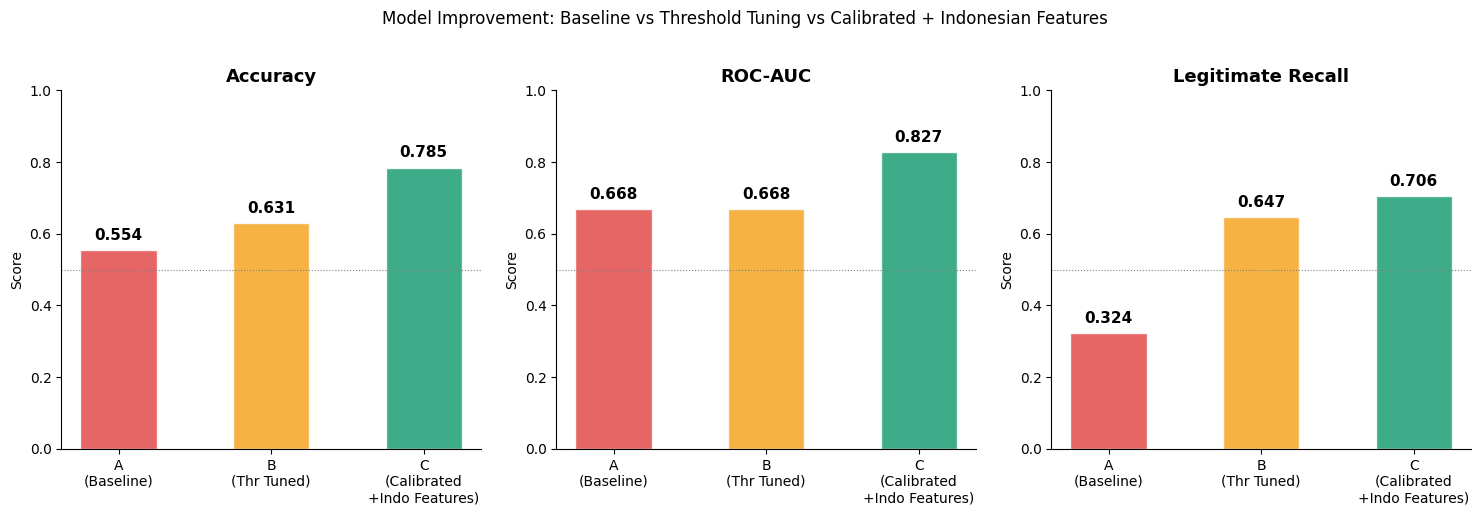

Saved: improvement_comparison.png


In [13]:
# ============================================================
# 11. VISUALIZE IMPROVEMENT
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

approaches = ['A\n(Baseline)', 'B\n(Thr Tuned)', 'C\n(Calibrated\n+Indo Features)']
colors     = ['#E24B4A', '#F5A623', '#1D9E75']

for ax, metric, vals, title in zip(
    axes,
    ['acc','auc','rec_leg'],
    [[r_A['acc'],r_B['acc'],r_C['acc']],
     [r_A['auc'],r_B['auc'],r_C['auc']],
     [r_A['rec_leg'],r_B['rec_leg'],r_C['rec_leg']]],
    ['Accuracy','ROC-AUC','Legitimate Recall']
):
    bars = ax.bar(approaches, vals, color=colors, alpha=0.85, width=0.5, edgecolor='white')
    ax.set_ylim(0, 1.0)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Model Improvement: Baseline vs Threshold Tuning vs Calibrated + Indonesian Features',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('improvement_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: improvement_comparison.png")


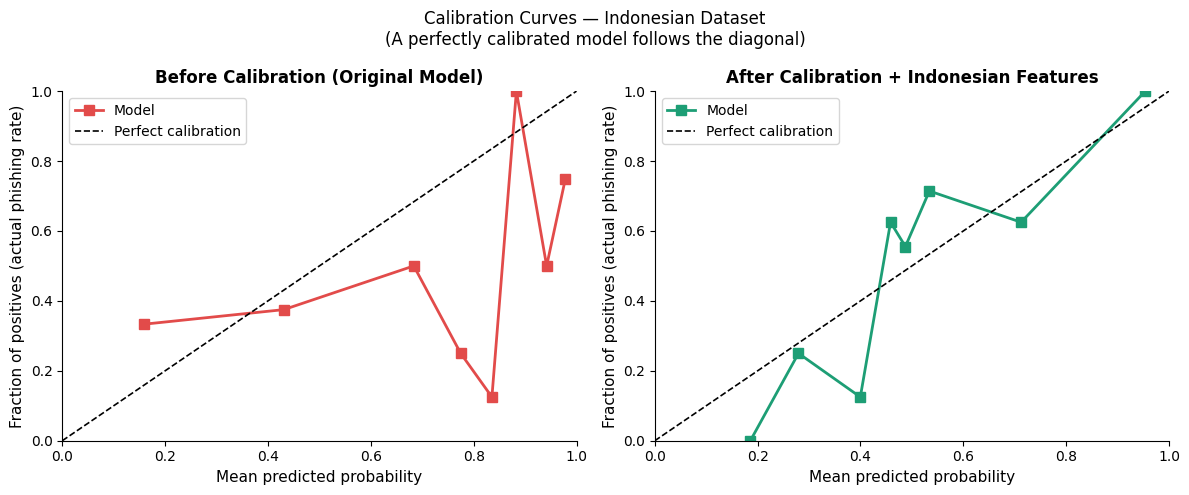

Saved: calibration_curve.png

How to read: If the line is ABOVE the diagonal, the model is under-confident.
If BELOW, it is over-confident (predicts high probabilities for things that are not phishing).
The original model is below the diagonal — classic over-confidence on Indonesian data.


In [14]:
# ============================================================
# 12. CALIBRATION CURVE — before vs after
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, probs, title, color in zip(
    axes,
    [y_prob_A,  y_prob_C],
    ['Before Calibration (Original Model)', 'After Calibration + Indonesian Features'],
    ['#E24B4A', '#1D9E75']
):
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=8, strategy='quantile')
    ax.plot(mean_pred, frac_pos, 's-', color=color, linewidth=2, markersize=7, label='Model')
    ax.plot([0,1],[0,1],'k--', linewidth=1.2, label='Perfect calibration')
    ax.set_xlabel('Mean predicted probability', fontsize=11)
    ax.set_ylabel('Fraction of positives (actual phishing rate)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend()
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Calibration Curves — Indonesian Dataset\n'
             '(A perfectly calibrated model follows the diagonal)', fontsize=12)
plt.tight_layout()
plt.savefig('calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: calibration_curve.png")
print()
print("How to read: If the line is ABOVE the diagonal, the model is under-confident.")
print("If BELOW, it is over-confident (predicts high probabilities for things that are not phishing).")
print("The original model is below the diagonal — classic over-confidence on Indonesian data.")


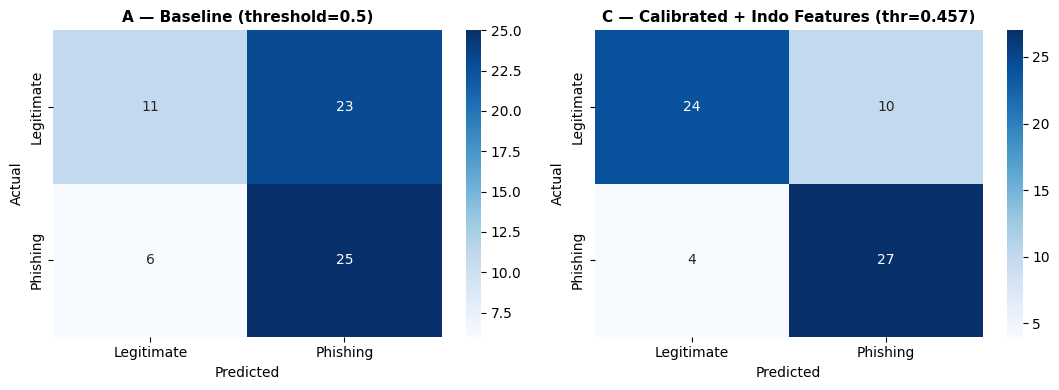

Saved: confusion_matrices_comparison.png


In [15]:
# ============================================================
# 13. CONFUSION MATRICES — A vs C
# ============================================================

cm_A = confusion_matrix(y_test, y_pred_A)
cm_C = confusion_matrix(y_test, y_pred_C_tuned)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, cm, title in zip(
    axes,
    [cm_A, cm_C],
    ['A — Baseline (threshold=0.5)',
     f'C — Calibrated + Indo Features (thr={best_thr_c:.3f})']
):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legitimate','Phishing'],
                yticklabels=['Legitimate','Phishing'])
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices_comparison.png")


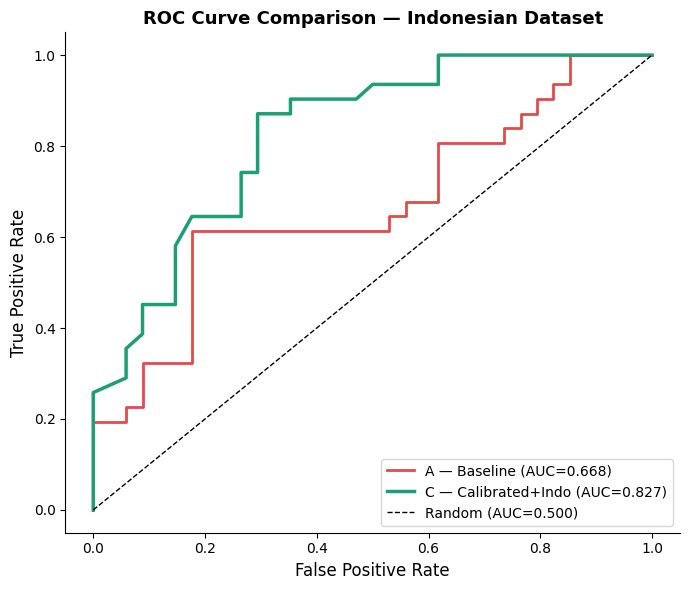

Saved: roc_comparison.png


In [16]:
# ============================================================
# 14. ROC CURVES — A, B, C overlay
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

for probs, label, color, lw in [
    (y_prob_A, f'A — Baseline (AUC={r_A["auc"]:.3f})',          '#E24B4A', 2),
    (y_prob_C, f'C — Calibrated+Indo (AUC={r_C["auc"]:.3f})',   '#1D9E75', 2.5),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, color=color, lw=lw, label=label)

ax.plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison — Indonesian Dataset', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_comparison.png")


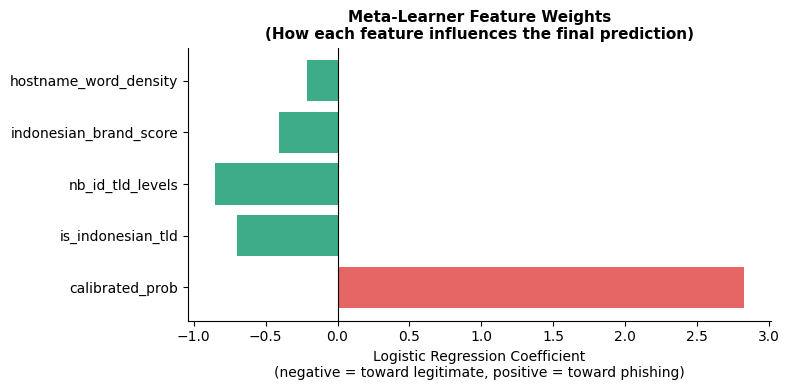

Meta-learner interpretation:
  calibrated_prob       coef=+2.828  → higher base prob = more phishing (expected)
  is_indonesian_tld              coef=-0.700  → reduces phishing prediction (helps Indonesian legitimate URLs)
  nb_id_tld_levels               coef=-0.855  → reduces phishing prediction (helps Indonesian legitimate URLs)
  indonesian_brand_score         coef=-0.408  → reduces phishing prediction (helps Indonesian legitimate URLs)
  hostname_word_density          coef=-0.214  → reduces phishing prediction (helps Indonesian legitimate URLs)


In [17]:
# ============================================================
# 15. SHAP — WHAT THE IMPROVED MODEL FOCUSES ON
# ============================================================
# The meta-learner has only 5 inputs so we can explain it directly.
# For deeper explanation, we still use XGBoost SHAP on the base model.

# Meta-learner feature importance (simple coefficient plot)
meta_coefs = meta_learner.coef_[0]
meta_feats = ['calibrated_prob','is_indonesian_tld','nb_id_tld_levels',
              'indonesian_brand_score','hostname_word_density']

fig, ax = plt.subplots(figsize=(8, 4))
colors_coef = ['#1D9E75' if c < 0 else '#E24B4A' for c in meta_coefs]
bars = ax.barh(meta_feats, meta_coefs, color=colors_coef, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic Regression Coefficient\n(negative = toward legitimate, positive = toward phishing)', fontsize=10)
ax.set_title('Meta-Learner Feature Weights\n(How each feature influences the final prediction)', fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('meta_learner_weights.png', dpi=150, bbox_inches='tight')
plt.show()

print("Meta-learner interpretation:")
for feat, coef in zip(meta_feats, meta_coefs):
    if feat == 'calibrated_prob':
        print(f"  calibrated_prob       coef={coef:+.3f}  → higher base prob = more phishing (expected)")
    elif coef < 0:
        print(f"  {feat:30s} coef={coef:+.3f}  → reduces phishing prediction (helps Indonesian legitimate URLs)")
    else:
        print(f"  {feat:30s} coef={coef:+.3f}  → increases phishing prediction")


In [18]:
# ============================================================
# 16. SAVE IMPROVED MODEL ARTIFACTS
# ============================================================

joblib.dump(iso_reg, 'calibrated_model.pkl')
joblib.dump(meta_learner,     'meta_learner.pkl')
joblib.dump(indo_scaler,      'indo_feature_scaler.pkl')

print("Saved artifacts:")
print("  calibrated_model.pkl     — isotonic-calibrated VotingClassifier")
print("  meta_learner.pkl         — LogisticRegression meta-learner (5 features)")
print("  indo_feature_scaler.pkl  — StandardScaler fitted on 4 Indonesian features")
print()
print("Inference pipeline for new URLs:")
print("  1. Extract 56 lexical features → scale with lexical_scaler.pkl")
print("  2. Compute 4 Indonesian features from raw URL string")
print("  3. Scale Indonesian features with indo_feature_scaler.pkl")
print("  4. prob = calibrated_model.predict_proba(X_56)[1]")
print("  5. meta = np.hstack([[prob], X_indo_4])")
print("  6. final_pred = meta_learner.predict(meta)")
print()

# Final summary
print("=" * 55)
print("FINAL RESULT SUMMARY")
print("=" * 55)
for approach, r in [("A — Baseline",r_A),("B — Thr Tuned",r_B),("C — Calibrated+Indo",r_C)]:
    print(f"{approach:35s}  AUC={r['auc']:.4f}  Acc={r['acc']:.4f}  LegitRecall={r['rec_leg']:.4f}")


Saved artifacts:
  calibrated_model.pkl     — isotonic-calibrated VotingClassifier
  meta_learner.pkl         — LogisticRegression meta-learner (5 features)
  indo_feature_scaler.pkl  — StandardScaler fitted on 4 Indonesian features

Inference pipeline for new URLs:
  1. Extract 56 lexical features → scale with lexical_scaler.pkl
  2. Compute 4 Indonesian features from raw URL string
  3. Scale Indonesian features with indo_feature_scaler.pkl
  4. prob = calibrated_model.predict_proba(X_56)[1]
  5. meta = np.hstack([[prob], X_indo_4])
  6. final_pred = meta_learner.predict(meta)

FINAL RESULT SUMMARY
A — Baseline                         AUC=0.6679  Acc=0.5538  LegitRecall=0.3235
B — Thr Tuned                        AUC=0.6679  Acc=0.6308  LegitRecall=0.6471
C — Calibrated+Indo                  AUC=0.8273  Acc=0.7846  LegitRecall=0.7059
